In [1]:
import torch
import pandas as pd
from tqdm import tqdm

from matplotlib import pyplot as plt
from matplotlib import ticker 

torch.manual_seed(42)

from dataclass import dataset

$$
\begin{array}{|c|l|c|c|}
\hline
 & \text{Reaction} & \text{Stoichiometry} & \text{Rate} \\
\hline
\text{Colonization} & \emptyset \to E & +1 & \alpha \\
\hline
\text{Replication} & E \to 2E & +1 & \mu E \\
\hline
\text{Competition} & E \to \emptyset & -1 & \left(\frac{\mu}{K}\right) E^2 \\
\hline
\text{Expulsion} & E \to \emptyset & -1 & dE \\
\hline
\end{array}
$$


In [2]:
# Loading the synthetic dataset
dseed = 0
df = pd.read_csv('synthetic_data/synth_seed{}.csv'.format(dseed))
df

,Time,Counts,Dilution
0,24.0,5,20.0
1,24.0,0,20.0
2,24.0,0,20.0
3,24.0,4,20.0
4,24.0,15,20.0
...,...,...,...
395,168.0,102,2000.0
396,168.0,129,2000.0
397,168.0,118,2000.0
398,168.0,94,2000.0


In [3]:
#Loading the ground truth

gt = pd.read_csv('synthetic_data/gt_map.csv', header=None, delim_whitespace=True).to_numpy()
gt = torch.tensor(gt[gt[:,0]==dseed][0,1:]).float()
gt

tensor([5.0000e-02, 2.5000e-01, 2.0000e+05, 1.0000e-03])

In [4]:
# The dataset need to be send to the `dataset` class
Ts     = df['Time'].to_numpy()
counts = df['Counts'].to_numpy()
dils   = df['Dilution'].to_numpy()
data = dataset(Ts,counts,dils)

Dataset loaded successfully.


In [5]:
#Define log posterior and check up in the lp_gt
value = torch.tensor( (1/20, 1/4, 2*1e5, 1e-3) ).to(data.device)
prior = torch.distributions.LogNormal(torch.log(value),torch.ones_like(value)*1/3)
logposterior = lambda value,data: data.loglike(value) + prior.log_prob(value).sum()

lp_gt = logposterior(gt.to(data.device),data)
lp_gt

tensor(3.2622, device='cuda:0', dtype=torch.float64)

In [6]:
def proposal(th,S_prop=1e-2):
    lth = torch.log(th)
    lprop = lth + torch.randn_like(th)*S_prop
    return torch.exp(lprop)

def next_MCMC_sample(params,lp):
    lp = logposterior(params,data) #not usually necessary but I dont wan't to bias

    params_prop = proposal(params)
    lp_prop = logposterior(params_prop,data)

    if torch.log(torch.rand(1)).item() < (lp_prop-lp).item():
        lp = lp_prop
        params = params_prop
    
    return params,lp
    
params = prior.sample()
lp = -torch.inf


In [7]:
N_burn = 300
N_mcmc = 1000

In [8]:
mcmc_params =[]
mcmc_lps = []

In [9]:
for s in tqdm(range(N_burn+N_mcmc)):
    if (s+1)%10 == 0:
        print(s+1, 'lp', lp.item())
        print(params.cpu().numpy())

    params,lp = next_MCMC_sample(params,lp)
    mcmc_params.append(params*1)
    mcmc_lps.append(lp.item())

  1%|          | 9/1300 [01:45<4:16:51, 11.94s/it]

10 lp -1.1101258166783738
[5.4037195e-02 2.6059613e-01 4.6042691e+05 7.0614793e-04]


  1%|▏         | 19/1300 [03:37<3:39:08, 10.26s/it]

20 lp -1.2628240039197776
[5.5301215e-02 2.6508659e-01 4.6127731e+05 6.9365249e-04]


  2%|▏         | 29/1300 [05:21<3:40:49, 10.42s/it]

...

 99%|█████████▉| 1289/1300 [3:13:04<01:18,  7.14s/it]

1290 lp 2.431310101141303
[4.8722848e-02 1.8356454e-01 2.7402853e+05 7.1947998e-04]


100%|█████████▉| 1299/1300 [3:14:15<00:07,  7.08s/it]

1300 lp 2.3327652293277543
[4.9352158e-02 1.8313196e-01 2.7886597e+05 7.1654073e-04]


100%|██████████| 1300/1300 [3:14:22<00:00,  8.97s/it]


In [10]:
posterior_samples = torch.stack(mcmc_params[-N_mcmc:]).cpu().numpy()

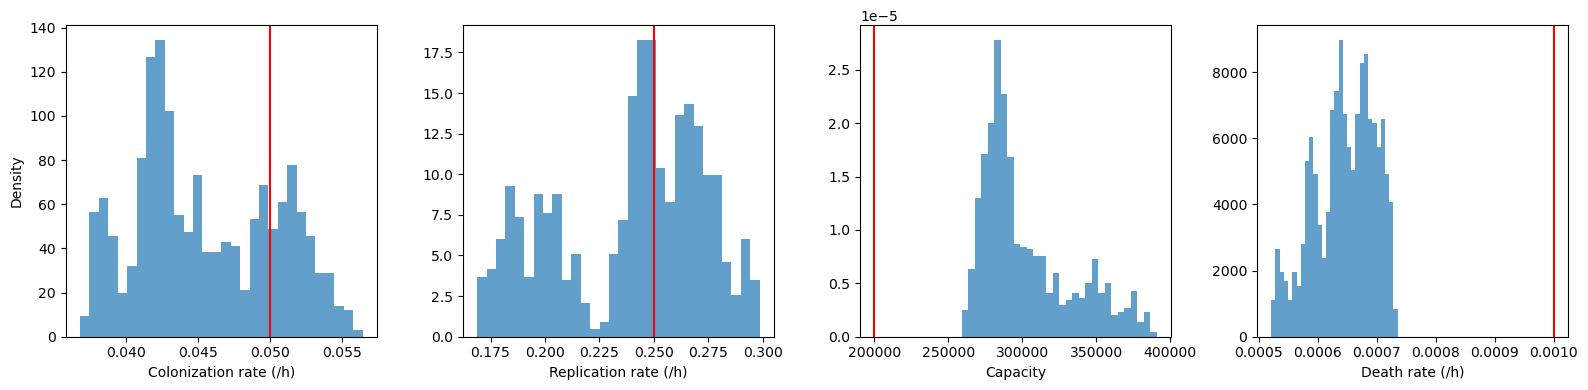

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Colonization rate (/h)','Replication rate (/h)','Capacity','Death rate (/h)']
for i in range(4):
    ax[i].hist(posterior_samples[:, i], bins=30, density=True, alpha=0.7)
    ax[i].set_xlabel(titles[i])
    ax[i].axvline(gt[i].item(),color='r')

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)

ax[0].set_ylabel('Density')
fig.tight_layout()
plt.show()

Text(0, 0.5, 'Log posterior')

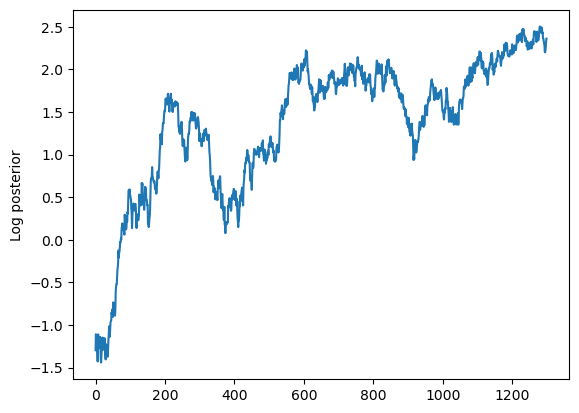

In [21]:
plt.plot(mcmc_lps)
plt.ylabel('Log posterior')